In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
from scipy.special import erf
import pyopencl as cl

%matplotlib notebook

plt.close()

# User Defined Parameters

In [2]:
### Beamline Parameters ###
Beamline = 'P10' #P10 or 8IDE
Geometry = 'Horizontal' #Horizontal or Vertical
Compound = 'NPS'

### Analysis Parameters ###


### File Parameters ###
Particle = 2 #2,3
Temperatures = np.array([298,305,325,345,365,385,405,350])
Scans = np.array([219,334,552,579,709,779,796,868]) # P3:[239,356
Attenuation = 20

Temperature = Temperatures[0]
Scan = Scans[0]
#Crop Size
#number of standard deviations from peak
Xv = 5
Xh = 5

In [ ]:
# Define the path to the configuration file
config_path = Path("config.json")

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)

#This is being written to handle multiple datasets of different formatting in different locations.
#Still working out the best way to handle, but base directories are now stored in a config.json file
#Subdirectories and file names still need to be defined here due to use of f-strings
if Compound == 'NBH':
    BASE_DIR       = Path(config.get("NBH_base"))
    dataset_name   = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001'
    subfolder      = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001'
    filename       = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001_001.hdf' 
    batchname      = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001_0001-3000.batchinfo' 
    #Set path to working directory
    work_path      = BASE_DIR / dataset_name 
    processed_path = work_path / 'processed'
if Compound == 'NPS':
    BASE_DIR       = Path(config.get("NPS_base"))
    dataset_name   = f'Particle_{Particle}/{Temperature}K/NPS_01_00{Scan}'
    subfolder      = 'e4m'
    filename       = f'{Compound}_01_00{Scan}_master.h5'
    batchname      = f'{Compound}_01_00{Scan}.batchinfo'
    #Set path to working directory
    work_path      = BASE_DIR / dataset_name / subfolder
    processed_path = work_path / 'processed'

#Check that path exists
if work_path.exists():
    print(f'Directory found: {work_path}')
else:
    print(f'Directory not found: {work_path}')

#Load File Names
file_list = np.sort(os.listdir(work_path)).tolist()

#Remove first element if it's DS_Store
if file_list[0] == '.DS_Store':
    file_list.remove(file_list[0])

#Removes strange file that occurs if you edit batchinfo
if file_list[0][0:2] == '._':
    file_list.remove(file_list[0])

print('Contains:') 
for f in file_list:
    print(f)

In [8]:
paths_list = []

for Temperature, Scan in zip(Temperatures,Scans):
    
    if Compound == 'NBH':
        processed_path = f'/Users/eriklamb/Desktop/NBH/A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001/processed/'

    if Compound == 'NPS':
        processed_path = f'/Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/XPCS_Scans/Particle_{Particle}/{Temperature}K/NPS_01_00{Scan}/processed/'

    #Check that path exists
    if not os.path.exists(processed_path):
        print(f"Directory '{processed_path}' Does Not Exist!")

    #Load File Names
    file_list = np.sort(os.listdir(processed_path)).tolist()

    #Remove first element if it's DS_Store
    if file_list[0] == '.DS_Store':
        file_list.remove(file_list[0])

    #Removes strange file that occurs if you edit batchinfo
    if file_list[0][0:2] == '._':
        file_list.remove(file_list[0])

    #for f in file_list:
        #print(f)

    #Retrieve number of files
    num_files = len(file_list)
    
    paths_list.append(processed_path+file_list[0])
    
#print(paths_list)

# Load Data

<IPython.core.display.Javascript object>


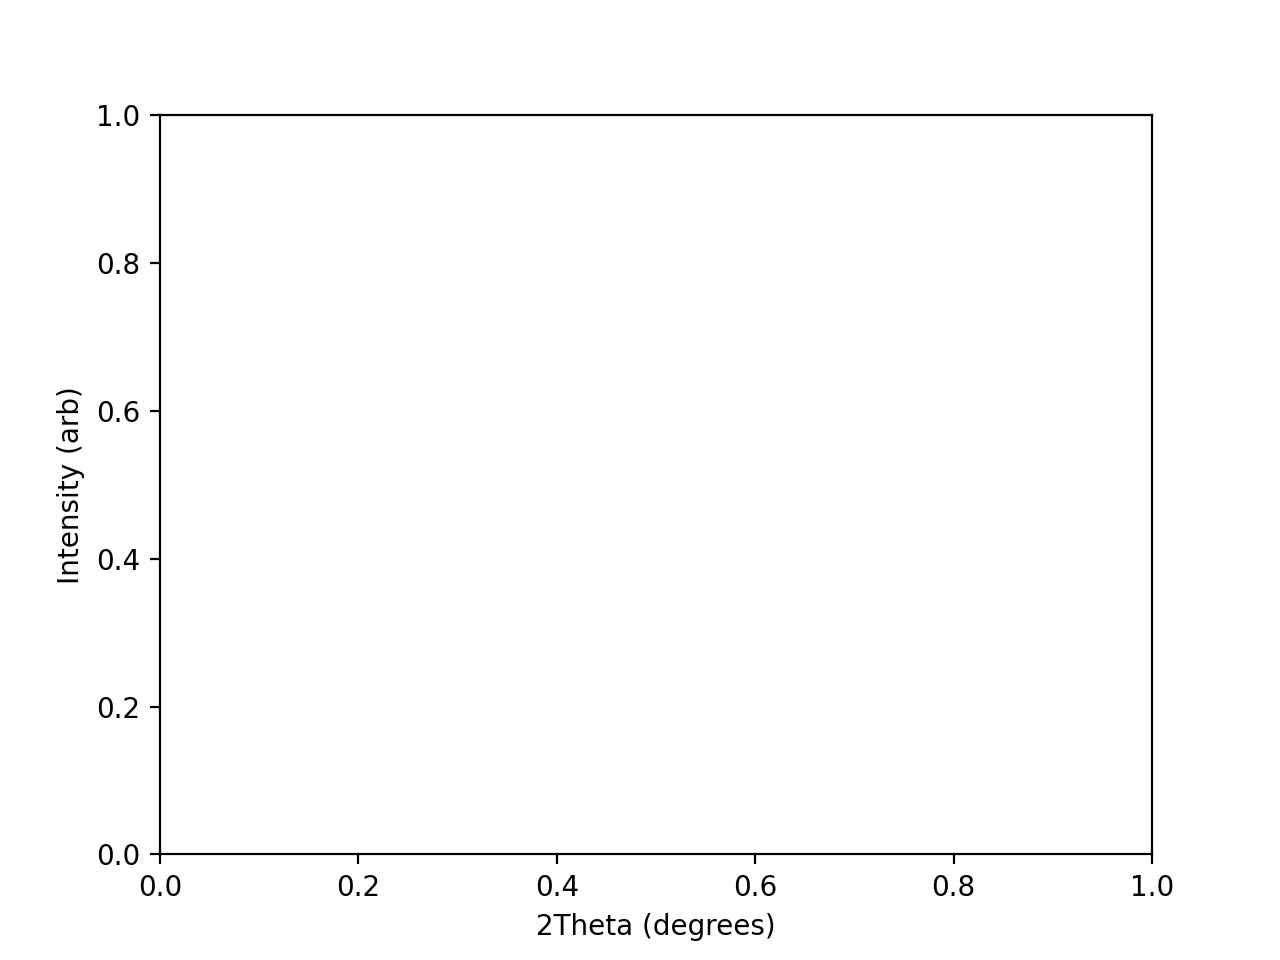

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_8863/1480954650.py:23: RuntimeWarning: invalid value encountered in scalar divide
  norm_INT = INTS / np.max(INTS)


ValueError: x and y must have same first dimension, but have shapes (370,) and (1,)

In [48]:
# first load
fig, ax = plt.subplots()

ax.set_xlabel('2Theta (degrees)')
ax.set_ylabel('Intensity (arb)')


# Define the vertical offset increment
offset_increment = 0.2

for i,(T,file) in enumerate(zip(np.flip(Temperatures),paths_list)):
    results = h5py.File(file, 'r')
    
    wavelength = results['experimental_parameters/wavelength'][:][0]
    det = results['data/det'][:]
    Qx = results['pre_processing/Qx'][:]
    Qy = results['pre_processing/Qy'][:]
    
    INTS = np.sum(np.mean(det[:20,0,0], axis=0), axis=0)
    TTH = q_to_tth(np.sqrt(Qx[det.shape[2]//2, :]**2 + Qy[det.shape[2]//2, :]**2), wavelength)

    # Normalize the intensities and add the offset
    norm_INT = INTS / np.max(INTS)
    offset = i * offset_increment  # Each curve gets an additional offset
    
    if T == 350:
        T = str(T)+ ' Cooling'
    ax.plot(TTH-offset, norm_INT, '-', label=T)
        
    results.close()

ax.legend(loc = 'upper left')    
plt.show()